In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


X_train = pd.read_csv('processed/splits/X_train_all.csv')
X_val = pd.read_csv('processed/splits/X_val_all.csv')
X_test = pd.read_csv('processed/splits/X_test_all.csv')

y_train = pd.read_csv('processed/splits/y_train_all.csv').squeeze()
y_val = pd.read_csv('processed/splits/y_val_all.csv').squeeze()
y_test = pd.read_csv('processed/splits/y_test_all.csv').squeeze()


classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Создаём словарь: {класс: вес}
class_weight_dict = dict(zip(classes, class_weights))


# Получаем уникальные классы
classes = np.unique(y_train)
print(f"Уникальных классов: {len(classes)}")

# Вычисляем веса по формуле: weight = n_samples / (n_classes * n_samples_in_class)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Создаём словарь: {класс: вес}
class_weight_dict = dict(zip(classes, class_weights))

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
#  Создаем массив весов для каждого объекта обучающей выборки
sample_weights = y_train.map(class_weight_dict)

Уникальных классов: 14


В данной работе применён подход AutoML с использованием библиотеки Optuna для подбора гиперпараметров модели XGBoost. Для ускорения процесса поиска была использована стратифицированная подвыборка обучающих данных (8%), которая позволила сократить время вычислений при сохранении представительности распределения классов. Оптимальные параметры были найдены путём минимизации метрики log-loss с применением эвристического алгоритма TPE и агентов раннего завершения (pruner). Финальная модель дообучена на полном объёме данных с учётом весов классов для компенсации дисбаланса

In [11]:
import os
import json
import joblib
import numpy as np
import optuna

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import log_loss
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from optuna.integration import XGBoostPruningCallback


# --------------------------
# CONFIG
# --------------------------
RANDOM_STATE = 42
N_TRIALS = 30                 # быстрый CPU-поиск (можно 50-80 при желании)
TRAIN_SAMPLE_FRAC = 0.08      # 8% train для Optuna (подберите 0.05..0.15)
EARLY_STOPPING_ROUNDS = 50
MODEL_DIR = "processed/models/xgb"
os.makedirs(MODEL_DIR, exist_ok=True)


# --------------------------
# 1) Encode labels -> int [0..K-1]
# --------------------------
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

num_classes_int = int(np.unique(y_train_encoded).size)
print(f"Classes: {num_classes_int}")
print(f"Class names: {le.classes_.tolist()}")


# --------------------------
# 2) Class weights -> sample_weight (multiclass-correct)
# --------------------------
classes_int = np.arange(num_classes_int)

class_weights_int = compute_class_weight(
    class_weight="balanced",
    classes=classes_int,
    y=y_train_encoded
)
weight_dict = dict(zip(classes_int, class_weights_int))

w_train = np.array([weight_dict[c] for c in y_train_encoded], dtype=np.float32)
w_val   = np.array([weight_dict[c] for c in y_val_encoded], dtype=np.float32)


# --------------------------
# 3) Stratified sample of TRAIN for faster Optuna
# --------------------------
sss = StratifiedShuffleSplit(n_splits=1, train_size=TRAIN_SAMPLE_FRAC, random_state=RANDOM_STATE)
idx_small, _ = next(sss.split(X_train, y_train_encoded))

X_train_s = X_train.iloc[idx_small]
y_train_s = y_train_encoded[idx_small]
w_train_s = w_train[idx_small]

print(f"Train full: {X_train.shape}, sampled: {X_train_s.shape}, Val: {X_val.shape}")


# --------------------------
# 4) Optuna objective
# --------------------------
def objective(trial: optuna.Trial) -> float:
    params = {
        "objective": "multi:softprob",
        "num_class": num_classes_int,
        "eval_metric": "mlogloss",
        "tree_method": "hist",           # CPU fast
        "random_state": RANDOM_STATE,
        "verbosity": 0,
        "n_jobs": 8,                     

        # ---- tuned params (CPU-friendly ranges) ----
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 2.0, 30.0, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 20.0, log=True),

        # hist speed knob
        "max_bin": trial.suggest_int("max_bin", 128, 512),

        # sometimes helps stability on imbalance/noise
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
    }

    model = XGBClassifier(**params, early_stopping_rounds=EARLY_STOPPING_ROUNDS)

    model.fit(
        X_train_s, y_train_s,
        sample_weight=w_train_s,
        eval_set=[(X_val, y_val_encoded)],
        sample_weight_eval_set=[w_val],
        verbose=False
    )

    proba = model.predict_proba(X_val)
    mll = log_loss(y_val_encoded, proba, labels=np.arange(num_classes_int))
    return float(mll)


# --------------------------
# 5) Run study (with pruning)
# --------------------------
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

study = optuna.create_study(
    direction="minimize",
    study_name="xgb_lsnm2024_cpu_fast_mlogloss",
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best mlogloss:", study.best_value)
print("Best params:", study.best_params)


# --------------------------
# 6) Train final model on FULL train (best params)
# --------------------------
best_params = study.best_params.copy()

final_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=num_classes_int,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=8,
    verbosity=0,
    early_stopping_rounds=200,   # можно больше на финальном обучении
)

final_model.fit(
    X_train, y_train_encoded,
    sample_weight=w_train,
    eval_set=[(X_val, y_val_encoded)],
    sample_weight_eval_set=[w_val],
    verbose=False
)

# --------------------------
# 7) Save artifacts
# --------------------------
joblib.dump(final_model, os.path.join(MODEL_DIR, "xgb_optuna_best.joblib"))
joblib.dump(le, os.path.join(MODEL_DIR, "label_encoder.joblib"))
joblib.dump(study, os.path.join(MODEL_DIR, "optuna_study.joblib"))

meta = {
    "metric_optimized": "mlogloss",
    "best_value": float(study.best_value),
    "best_params": {k: (float(v) if isinstance(v, (np.floating,)) else int(v) if isinstance(v, (np.integer,)) else v)
                   for k, v in study.best_params.items()},
    "n_trials": int(len(study.trials)),
    "train_sample_frac_for_optuna": float(TRAIN_SAMPLE_FRAC),
    "early_stopping_rounds_optuna": int(EARLY_STOPPING_ROUNDS),
    "features_count": int(X_train.shape[1]),
    "n_classes": int(num_classes_int),
    "class_names": le.classes_.tolist(),
}
with open(os.path.join(MODEL_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"Saved model + encoder + study to: {MODEL_DIR}")

# --------------------------
# 8) Example: predict on test (strings)
# --------------------------
test_proba = final_model.predict_proba(X_test)
test_pred_int = np.argmax(test_proba, axis=1)
test_pred_str = le.inverse_transform(test_pred_int)
print("Test predictions (example):", test_pred_str[:5].tolist())

Classes: 14
Class names: ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']


[I 2026-03-05 21:27:19,832] A new study created in memory with name: xgb_lsnm2024_cpu_fast_mlogloss


Train full: (3180741, 55), sampled: (254459, 55), Val: (681587, 55)


Best trial: 0. Best value: 0.0507481:   3%|▎         | 1/30 [01:05<31:27, 65.08s/it]

[I 2026-03-05 21:28:24,914] Trial 0 finished with value: 0.050748065353510875 and parameters: {'n_estimators': 425, 'learning_rate': 0.1785436060870726, 'max_depth': 7, 'min_child_weight': 10.118287286592736, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 6.054365855469246, 'max_bin': 400, 'max_delta_step': 0}. Best is trial 0 with value: 0.050748065353510875.


...

[I 2026-03-05 22:07:41,587] Trial 27 finished with value: 0.054388477433607134 and parameters: {'n_estimators': 392, 'learning_rate': 0.10713108974993554, 'max_depth': 6, 'min_child_weight': 7.667350794269411, 'subsample': 0.9242557191887588, 'colsample_bytree': 0.6249828115416673, 'gamma': 2.3248172045154627, 'reg_alpha': 1.783079154120065, 'reg_lambda': 2.078050038350772, 'max_bin': 430, 'max_delta_step': 6}. Best is trial 24 with value: 0.04912037514851151.


Best trial: 28. Best value: 0.048425:  97%|█████████▋| 29/30 [43:37<01:50, 110.52s/it]

[I 2026-03-05 22:10:57,666] Trial 28 finished with value: 0.0484249750188659 and parameters: {'n_estimators': 689, 'learning_rate': 0.05744840102146592, 'max_depth': 5, 'min_child_weight': 4.7712494914932035, 'subsample': 0.840232757969999, 'colsample_bytree': 0.5423564401909056, 'gamma': 0.3623406130599373, 'reg_alpha': 1.4268277433381615, 'reg_lambda': 1.2489486876716254, 'max_bin': 473, 'max_delta_step': 7}. Best is trial 28 with value: 0.0484249750188659.


Best trial: 28. Best value: 0.048425: 100%|██████████| 30/30 [45:59<00:00, 91.98s/it] 


[I 2026-03-05 22:13:19,170] Trial 29 finished with value: 0.04965019544870753 and parameters: {'n_estimators': 683, 'learning_rate': 0.06017628983475712, 'max_depth': 5, 'min_child_weight': 3.9187107584007843, 'subsample': 0.8337829676497468, 'colsample_bytree': 0.5878247756640171, 'gamma': 0.30683225075862247, 'reg_alpha': 1.1443187837844038, 'reg_lambda': 19.59897341639895, 'max_bin': 387, 'max_delta_step': 8}. Best is trial 28 with value: 0.0484249750188659.
Best mlogloss: 0.0484249750188659
Best params: {'n_estimators': 689, 'learning_rate': 0.05744840102146592, 'max_depth': 5, 'min_child_weight': 4.7712494914932035, 'subsample': 0.840232757969999, 'colsample_bytree': 0.5423564401909056, 'gamma': 0.3623406130599373, 'reg_alpha': 1.4268277433381615, 'reg_lambda': 1.2489486876716254, 'max_bin': 473, 'max_delta_step': 7}
Saved model + encoder + study to: processed/models/xgb
Test predictions (example): ['SYN-Flood', 'DDoS', 'RCE', 'DDoS', 'RCE']


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


MODEL_DIR = "processed/models/xgb"
DATA_DIR = "processed/splits"

# Загружаем модель
final_model = joblib.load(os.path.join(MODEL_DIR, "xgb_optuna_best.joblib"))
print(f"✅ Модель загружена: {os.path.join(MODEL_DIR, 'xgb_optuna_best.joblib')}")

# Загружаем LabelEncoder для преобразования меток в строки
le = joblib.load(os.path.join(MODEL_DIR, "label_encoder.joblib"))
print(f"✅ LabelEncoder загружен: {os.path.join(MODEL_DIR, 'label_encoder.joblib')}")

✅ Модель загружена: processed/models/xgb\xgb_optuna_best.joblib
✅ LabelEncoder загружен: processed/models/xgb\label_encoder.joblib


In [13]:
print("\n🔧 Подготовка целевой переменной...")

y_val_encoded = le.transform(y_val)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

num_classes = len(le.classes_)
print(f"Количество классов: {num_classes}")
print(f"Классы: {le.classes_.tolist()}")



🔧 Подготовка целевой переменной...
Количество классов: 14
Классы: ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']


In [14]:
# Валидация
y_val_pred = final_model.predict(X_val)
y_val_proba = final_model.predict_proba(X_val)

# Тренировочная выборка (для проверки переобучения)
y_train_pred = final_model.predict(X_train)

# Тестовая выборка
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

print("✅ Все предсказания выполнены")

✅ Все предсказания выполнены


In [15]:
train_acc = accuracy_score(y_train_encoded, y_train_pred)
val_acc = accuracy_score(y_val_encoded, y_val_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

print(f"\nAccuracy:")
print(f"   Train Accuracy:      {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Val Accuracy:        {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")

macro_f1 = f1_score(y_val_encoded, y_val_pred, average='macro')
weighted_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')

print(f"\nF1-Score:")
print(f"   Macro F1:            {macro_f1:.4f}")
print(f"   Weighted F1:         {weighted_f1:.4f}")

roc_macro = roc_auc_score(y_val_encoded, y_val_proba, average='macro', multi_class='ovr')
roc_micro = roc_auc_score(y_val_encoded, y_val_proba, average='micro', multi_class='ovr')

print(f"\nROC-AUC:")
print(f"   Macro AUC:           {roc_macro:.4f}")
print(f"   Micro AUC:           {roc_micro:.4f}")



Accuracy:
   Train Accuracy:      0.9800 (98.00%)
   Val Accuracy:        0.9796 (97.96%)
   Test Accuracy:       0.9797 (97.97%)

F1-Score:
   Macro F1:            0.9749
   Weighted F1:         0.9798

ROC-AUC:
   Macro AUC:           0.9997
   Micro AUC:           0.9999


In [16]:
overfitting_diff = abs(train_acc - val_acc)

print(f"\nРазница Train vs Validation: {overfitting_diff:.4f} ({overfitting_diff*100:.2f}%)")

if overfitting_diff < 0.02:
    print(f"   ✅ Переобучения не обнаружено (разница < 2%)")
elif overfitting_diff < 0.05:
    print(f"   ⚠️ Умеренная разница — возможно небольшое переобучение")
else:
    print(f"   ❌ Значительная разница (>5%) — возможен сильный overfitting")
    print(f"   💡 Рекомендация: уменьшить max_depth или добавить regularisation")


Разница Train vs Validation: 0.0004 (0.04%)
   ✅ Переобучения не обнаружено (разница < 2%)


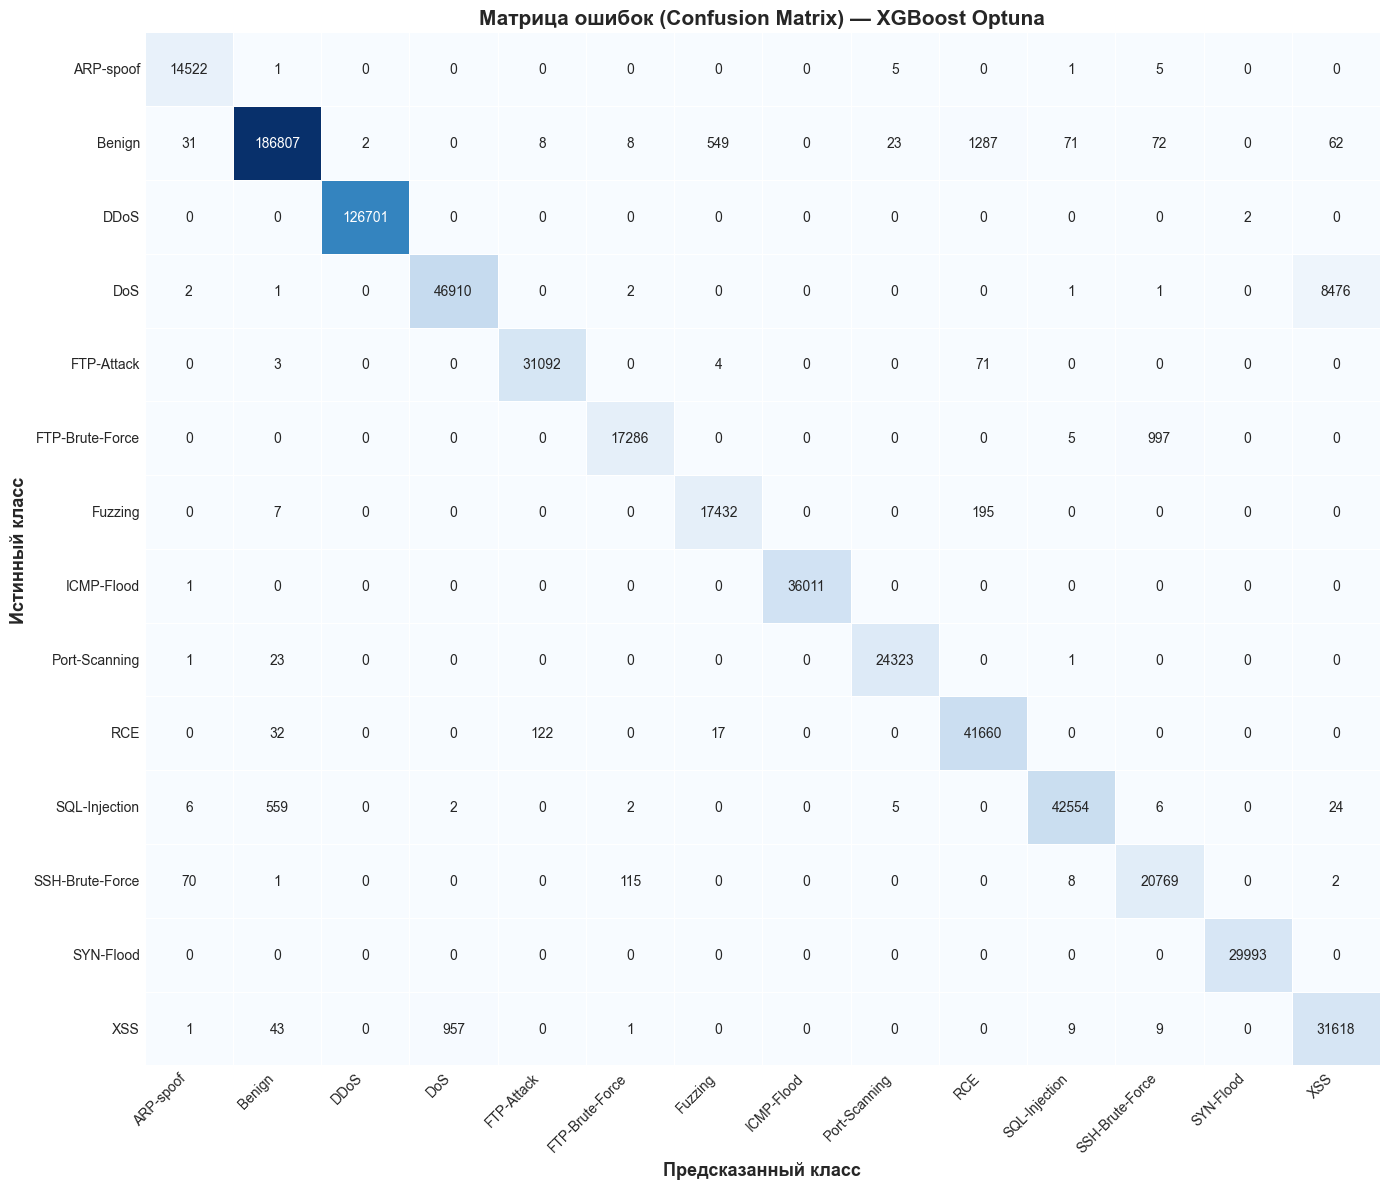

 Confusion Matrix сохранена: processed/models/confusion_matrix_xgb_optuna.png


In [17]:
cm = confusion_matrix(y_val_encoded, y_val_pred)

unique_classes = np.unique(np.concatenate([y_val_encoded, y_val_pred]))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False, 
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.xlabel('Предсказанный класс', fontsize=13, fontweight='bold')
plt.ylabel('Истинный класс', fontsize=13, fontweight='bold')
plt.title('Матрица ошибок (Confusion Matrix) — XGBoost Optuna', 
          fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_path = "processed/models/confusion_matrix_xgb_optuna.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" Confusion Matrix сохранена: {output_path}")

In [21]:
misclassified_mask = (y_val_encoded != y_val_pred)
if misclassified_mask.sum() > 0:
    errors_df = pd.DataFrame({
        'true': y_val_encoded[misclassified_mask],
        'pred': y_val_pred[misclassified_mask]
    })
    
    error_pairs = errors_df.groupby(['true', 'pred']).size().reset_index(name='count')
    top_errors = error_pairs.sort_values('count', ascending=False).head(10)
    
    print(f"Топ-10 наиболее частых ошибок:")
    for _, row in top_errors.iterrows():
        true_cls = le.classes_[int(row['true'])]
        pred_cls = le.classes_[int(row['pred'])]
        count = int(row['count'])
        percentage = count / misclassified_mask.sum() * 100
        print(f"   • {true_cls:<20s} → {pred_cls:<20s} : {count:>6} случаев ({percentage:.1f}%)")
else:
    print("   Нет ошибок! Перепроверьте параметры для обучения или выборки датасета!")


Топ-10 наиболее частых ошибок:
   • DoS                  → XSS                  :   8476 случаев (60.9%)
   • Benign               → RCE                  :   1287 случаев (9.3%)
   • FTP-Brute-Force      → SSH-Brute-Force      :    997 случаев (7.2%)
   • XSS                  → DoS                  :    957 случаев (6.9%)
   • SQL-Injection        → Benign               :    559 случаев (4.0%)
   • Benign               → Fuzzing              :    549 случаев (3.9%)
   • Fuzzing              → RCE                  :    195 случаев (1.4%)
   • RCE                  → FTP-Attack           :    122 случаев (0.9%)
   • SSH-Brute-Force      → FTP-Brute-Force      :    115 случаев (0.8%)
   • Benign               → SSH-Brute-Force      :     72 случаев (0.5%)


In [ ]:
import os, json, joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder  
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# === ПРЕОБРАЗОВАНИЕ СТРОКОВЫХ МЕТОК В ЧИСЛОВЫЕ ===
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # 'Benign' → 0, 'DDoS' → 1, ...
y_val_encoded = le.transform(y_val)

classes = np.unique(y_train_encoded)
num_classes_int = len(classes)

print(f"Число классов после кодирования: {num_classes_int}")
print(f"Метки классов: {list(range(num_classes_int))}")
print(f"Названия классов: {le.classes_.tolist()}")

# Вычисляем веса классов для ИНТЕГЕРНЫХ меток
class_weights_int = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_encoded
)
# Создаём словарь {int_class: weight} для быстрого доступа
weight_dict = dict(zip(classes, class_weights_int))

w_train = np.array([weight_dict[c] for c in y_train_encoded])
w_val   = np.array([weight_dict[c] for c in y_val_encoded]) 

def objective(trial):
    params = {
        'objective': 'multi:softprob',          # Многоклассовая классификация
        'num_class': num_classes_int,            # ← ИСПРАВЛЕНО: теперь числовое
        "tree_method": "hist",              # быстро и стабильно; если GPU: "gpu_hist"
        "eval_metric": "mlogloss",
        "random_state": 42,
         # --- основные гиперпараметры ---
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 20.0, log=True),

        # полезно при дисбалансе/шуме
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),

        # чтобы не ловить лишние предупреждения
        "verbosity": 0,
        "n_jobs": 8,
    }

    model = XGBClassifier(**params, early_stopping_rounds=200)

    model.fit(
        X_train, y_train_encoded,  
        sample_weight=w_train,
        eval_set=[(X_val, y_val_encoded)],  
        sample_weight_eval_set=[w_val],
        verbose=False,
        
    )

    # берём вероятности
    proba = model.predict_proba(X_val)  
    mll = log_loss(y_val_encoded, proba, labels=np.arange(num_classes_int)) 

    # можно дополнительно логировать вторичные метрики в trial.user_attrs
    pred = np.argmax(proba, axis=1)
    trial.set_user_attr("val_accuracy", float(accuracy_score(y_val_encoded, pred)))
    trial.set_user_attr("val_bal_acc", float(balanced_accuracy_score(y_val_encoded, pred)))
    trial.set_user_attr("val_macro_f1", float(f1_score(y_val_encoded, pred, average="macro")))

    return mll 

study = optuna.create_study(direction="minimize", study_name="xgb_lsnm2024_mlogloss",sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=10, timeout=None, show_progress_bar=True)

print("Best mlogloss:", study.best_value)
print("Best params:", study.best_params)

best_model = study.best_trial.params
print("\nЛучшая модель:")
for key, value in best_model.items():
    print(f"  {key}: {value}")

# Сохраняем лучшую модель с обученными весами
final_model = XGBClassifier(**best_model, random_state=42)
final_model.fit(X_train, y_train_encoded, sample_weight=w_train)

joblib.dump(final_model, 'processed/models/xgb/xgb_optuna_best.pkl')
print("\nЛучшая модель сохранена: processed/models/xgb/xgb_optuna_best.pkl")

# Сохраняем LabelEncoder для будущего использования
joblib.dump(le, 'processed/models/xgb/label_encoder.pkl')
print("LabelEncoder сохранён: models/xgb/label_encoder.pkl")

# Обратное преобразование предсказаний
test_pred_proba = final_model.predict_proba(X_test)
test_pred_int = np.argmax(test_pred_proba, axis=1)
test_pred_str = le.inverse_transform(test_pred_int)
print(f"\nПримеры предсказаний на Test (строки): {test_pred_str[:5].tolist()}")

Число классов после кодирования: 14
Метки классов: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Названия классов: ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']


[I 2026-03-05 21:18:02,712] A new study created in memory with name: xgb_lsnm2024_mlogloss
  0%|          | 0/10 [01:18<?, ?it/s]

[W 2026-03-05 21:19:21,333] Trial 0 failed with parameters: {'n_estimators': 425, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 6.009974718380312, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.5808361216819946, 'reg_alpha': 4.330880728874676, 'reg_lambda': 4.591898870587326, 'max_delta_step': 7} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\аля\AppData\Local\Temp\ipykernel_14092\1184697375.py", line 61, in objective
    model.fit(
  File "d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\xgboost\sklearn.py", line 1806, in fit
    

KeyboardInterrupt: 